# RC-POC Architecture Analysis
## Does Concentration Help Classification, or Vice Versa?

This notebook evaluates four architectures across **7 datasets × 4 SupCon settings (N=28 paired observations)**
to answer the core research question.

| # | Model | Role |
|---|---|---|
| 1 | `cgd_rc_poc` | **Pure Cls** — CNN+GRU, no concentration supervision |
| 2 | `mtl_cgd_rc_poc` | **MTL** — Joint classification + regression |
| 3 | `gru_rcfd_cgd_rc_poc` | **RCFD** — GRU predicts concentration → FiLM → classifies |
| 4 | `gru_ccfd_cgd_rc_poc` | **CCFD-POC** — Frozen classifier → FiLM → regression |

**Hypothesis A:** Concentration supervision improves classification (MTL ≻ CGD, RCFD ≻ CGD).  
**Hypothesis B:** Classification features improve regression (CCFD-POC ≻ MTL, CCFD-POC ≻ RCFD).

In [4]:
import os
import joblib
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.lines import Line2D
from sklearn.metrics import accuracy_score
from pathlib import Path
from collections import OrderedDict

%matplotlib inline
matplotlib.rcParams.update({
    'font.size': 11,
    'axes.titlesize': 13,
    'axes.labelsize': 12,
    'figure.dpi': 110,
    'savefig.bbox': 'tight',
})

# ─── paths ────────────────────────────────────────────────────────────────────
DATA_ROOT = Path('/vol/bitbucket/gk225/POC_DDM_datasets/LAB_DDM_paper')
REG_SENTINEL = -9999.0

# ─── dataset ordering + display labels ───────────────────────────────────────
DATASETS_ORDER = [
    '01_ACA_qdPCR',
    '03_AMCA_qdPCR',
    '07_ACA_qdPCR_conc_filtered',
    '08_AMCA_qdPCR_conc_filtered',
    '09_Area_Conc',
    '10_Range_Conc',
    '02_AMCA_qdLAMP',
]

DS_LABELS = {
    '01_ACA_qdPCR':                  'ACA qdPCR',
    '02_AMCA_qdLAMP':                'AMCA qdLAMP',
    '03_AMCA_qdPCR':                 'AMCA qdPCR',
    '07_ACA_qdPCR_conc_filtered':    'ACA qdPCR (conc-filt)',
    '08_AMCA_qdPCR_conc_filtered':   'AMCA qdPCR (conc-filt)',
    '09_Area_Conc':                  'Area+Conc',
    '10_Range_Conc':                 'Range+Conc',
}

# ─── model families ───────────────────────────────────────────────────────────
CLS_KEYS  = ['cgd_rc_poc', 'cgd_rc_poc_sc1', 'cgd_rc_poc_sc2', 'cgd_rc_poc_sc3']
MTL_KEYS  = ['mtl_cgd_rc_poc', 'mtl_cgd_rc_poc_sc1', 'mtl_cgd_rc_poc_sc2', 'mtl_cgd_rc_poc_sc3']
RCFD_KEYS = ['gru_rcfd_cgd_rc_poc', 'gru_rcfd_cgd_rc_poc_sc1', 'gru_rcfd_cgd_rc_poc_sc2', 'gru_rcfd_cgd_rc_poc_sc3']
CCFD_KEYS = ['gru_ccfd_cgd_rc_poc', 'gru_ccfd_cgd_rc_poc_sc1', 'gru_ccfd_cgd_rc_poc_sc2', 'gru_ccfd_cgd_rc_poc_sc3']

FAMILIES = OrderedDict([
    ('CGD',      CLS_KEYS),
    ('MTL',      MTL_KEYS),
    ('RCFD',     RCFD_KEYS),
    ('CCFD-POC', CCFD_KEYS),
])

FAMILY_LABEL = {
    'CGD':      'CGD (pure cls)',
    'MTL':      'MTL (joint cls+reg)',
    'RCFD':     'RCFD (reg→FiLM→cls)',
    'CCFD-POC': 'CCFD-POC (frozen cls→FiLM→reg)',
}

# dark→light per SC level (SC0 darkest, SC3 lightest)
FCOLORS = {
    'CGD':      ['#0D47A1', '#1565C0', '#1E88E5', '#64B5F6'],
    'MTL':      ['#1B5E20', '#2E7D32', '#43A047', '#81C784'],
    'RCFD':     ['#BF360C', '#E64A19', '#FF7043', '#FFAB91'],
    'CCFD-POC': ['#4A148C', '#7B1FA2', '#AB47BC', '#CE93D8'],
}

FAMILY_REPR_COLOR = {f: cs[1] for f, cs in FCOLORS.items()}  # SC1 color as representative

SC_LABELS = ['SC0', 'SC1', 'SC2', 'SC3']
print('Setup complete.')

Setup complete.


In [5]:
# ─── load all rc_poc results ──────────────────────────────────────────────────

def compute_rmse(reg_trues_list, reg_preds_list):
    rmses = []
    for rt, rp in zip(reg_trues_list, reg_preds_list):
        rt, rp = np.asarray(rt, float), np.asarray(rp, float)
        v = (rt != REG_SENTINEL) & np.isfinite(rt) & np.isfinite(rp)
        if v.sum() >= 2:
            rmses.append(np.sqrt(np.mean((rt[v] - rp[v]) ** 2)))
    return np.mean(rmses) if rmses else np.nan

def get_conc_mean(res):
    """Mean concentration across all folds (for normalisation)."""
    for key in res:
        if key.startswith('y_reg_trues_'):
            all_rt = np.concatenate([np.asarray(rt, float) for rt in res[key]])
            valid  = all_rt[(all_rt != REG_SENTINEL) & np.isfinite(all_rt)]
            return valid.mean() if len(valid) else np.nan
    return np.nan

# Raw accuracy (%) and RMSE per dataset × model
cls_data  = {}   # {ds_id: {model_key: accuracy_pct}}
reg_data  = {}   # {ds_id: {model_key: rmse}}
conc_mean = {}   # {ds_id: mean_concentration}  — for normalisation

for ds_id in DATASETS_ORDER:
    fp = DATA_ROOT / ds_id / 'rc_poc' / 'rc_poc_results.joblib'
    if not fp.exists():
        print(f'  [MISSING] {ds_id}')
        continue
    d = joblib.load(fp)

    res = None
    for _, mode_dict in d.items():
        for _, res_dict in mode_dict.items():
            for _, r in res_dict.items():
                if isinstance(r, dict) and 'y_trues_' in r:
                    res = r
                    break
    if res is None:
        print(f'  [NO DATA] {ds_id}'); continue

    y_trues = res['y_trues_']
    cls_data[ds_id]  = {}
    reg_data[ds_id]  = {}
    conc_mean[ds_id] = get_conc_mean(res)

    for family, keys in FAMILIES.items():
        for key in keys:
            pk  = f'y_preds_AC_{key}_'
            rpk = f'y_reg_preds_{key}_'
            rtk = f'y_reg_trues_{key}_'

            if pk in res:
                accs = [accuracy_score(yt, yp) for yt, yp in zip(y_trues, res[pk])]
                cls_data[ds_id][key] = np.mean(accs) * 100

            if rpk in res and rtk in res:
                reg_data[ds_id][key] = compute_rmse(res[rtk], res[rpk])

# Summary DataFrame for convenience
rows = []
for ds_id in DATASETS_ORDER:
    for family, keys in FAMILIES.items():
        for sc_idx, key in enumerate(keys):
            acc  = cls_data.get(ds_id, {}).get(key, np.nan)
            rmse = reg_data.get(ds_id, {}).get(key, np.nan)
            cmean = conc_mean.get(ds_id, np.nan)
            rows.append(dict(
                dataset=ds_id, ds_label=DS_LABELS[ds_id],
                family=family, model_key=key, sc=sc_idx,
                accuracy=acc, rmse=rmse,
                rmse_pct=rmse / cmean * 100 if (not np.isnan(rmse) and cmean > 0) else np.nan,
            ))

df = pd.DataFrame(rows)
print(f'Loaded {len(df)} rows × {len(DATASETS_ORDER)} datasets')
df.groupby('family')[['accuracy', 'rmse_pct']].mean().round(2)

Loaded 112 rows × 7 datasets


,accuracy,rmse_pct
family,,
CCFD-POC,NaN,49.11
CGD,95.08,NaN
MTL,94.97,39.40
RCFD,94.87,41.31


In [6]:
# ─── Master DataFrame — all raw results ───────────────────────────────────────
CLS_KEY_SET = set(CLS_KEYS)
REG_KEY_SET = set(MTL_KEYS + RCFD_KEYS + CCFD_KEYS)

rows_raw = []
for ds_id in DATASETS_ORDER:
    cmean = conc_mean.get(ds_id, np.nan)
    for family, keys in FAMILIES.items():
        for sc_idx, key in enumerate(keys):
            acc  = cls_data.get(ds_id, {}).get(key, np.nan)
            rmse = reg_data.get(ds_id, {}).get(key, np.nan)
            rows_raw.append({
                'dataset':      DS_LABELS[ds_id],
                'dataset_id':   ds_id,
                'family':       family,
                'model_key':    key,
                'sc':           sc_idx,
                'has_cls':      key not in set(CCFD_KEYS),
                'has_reg':      key in REG_KEY_SET,
                'accuracy_pct': acc,
                'rmse':         rmse,
                'rmse_pct':     rmse / cmean * 100 if (not np.isnan(rmse) and cmean > 0) else np.nan,
                'conc_mean':    cmean,
            })

raw_df = pd.DataFrame(rows_raw)[[
    'dataset', 'family', 'sc', 'model_key',
    'accuracy_pct', 'rmse', 'rmse_pct',
    'has_cls', 'has_reg', 'conc_mean', 'dataset_id',
]]

print(f'Shape: {raw_df.shape}  ({len(DATASETS_ORDER)} datasets × 16 models)')
print(f'NaN accuracy (CCFD-POC, no cls): {raw_df["accuracy_pct"].isna().sum()}')
print(f'NaN rmse (CGD, no reg): {raw_df["rmse"].isna().sum()}')
print()
with pd.option_context('display.max_rows', 20, 'display.float_format', '{:.3f}'.format):
    display(raw_df)


Shape: (112, 11)  (7 datasets × 16 models)
NaN accuracy (CCFD-POC, no cls): 28
NaN rmse (CGD, no reg): 28



,dataset,family,sc,model_key,accuracy_pct,rmse,rmse_pct,has_cls,has_reg,conc_mean,dataset_id
0,ACA qdPCR,CGD,0,cgd_rc_poc,99.382,NaN,NaN,True,False,445825.093,01_ACA_qdPCR
1,ACA qdPCR,CGD,1,cgd_rc_poc_sc1,99.320,NaN,NaN,True,False,445825.093,01_ACA_qdPCR
2,ACA qdPCR,CGD,2,cgd_rc_poc_sc2,99.444,NaN,NaN,True,False,445825.093,01_ACA_qdPCR
3,ACA qdPCR,CGD,3,cgd_rc_poc_sc3,99.506,NaN,NaN,True,False,445825.093,01_ACA_qdPCR
4,ACA qdPCR,MTL,0,mtl_cgd_rc_poc,99.506,158776.224,35.614,True,True,445825.093,01_ACA_qdPCR
...,...,...,...,...,...,...,...,...,...,...,...
107,AMCA qdLAMP,RCFD,3,gru_rcfd_cgd_rc_poc_sc3,97.638,1991186.298,24.346,True,True,8178709.487,02_AMCA_qdLAMP
108,AMCA qdLAMP,CCFD-POC,0,gru_ccfd_cgd_rc_poc,NaN,3846923.613,47.036,False,True,8178709.487,02_AMCA_qdLAMP
109,AMCA qdLAMP,CCFD-POC,1,gru_ccfd_cgd_rc_poc_sc1,NaN,1867781.890,22.837,False,True,8178709.487,02_AMCA_qdLAMP
110,AMCA qdLAMP,CCFD-POC,2,gru_ccfd_cgd_rc_poc_sc2,NaN,1737914.163,21.249,False,True,8178709.487,02_AMCA_qdLAMP


## Architecture Mapping
Map raw model keys to the four analytical families.

In [7]:
ARCH_MAP = {
    'CGD':      '(1) CGD – Pure Cls',
    'MTL':      '(2) MTL – Joint Cls+Reg',
    'RCFD':     '(3) RCFD – Reg→Cls',
    'CCFD-POC': '(4) CCFD-POC – Frozen Cls→Reg',
}
df = raw_df.copy()
df['arch'] = df['family'].map(ARCH_MAP)

print(f'N = {len(df)} rows  ({len(DATASETS_ORDER)} datasets × 16 models)')
print(f'Cls rows (has_cls=True): {df.has_cls.sum()}   Reg rows (has_reg=True): {df.has_reg.sum()}')
display(df[['dataset','arch','sc','accuracy_pct','rmse','rmse_pct']].head(8))

N = 112 rows  (7 datasets × 16 models)
Cls rows (has_cls=True): 84   Reg rows (has_reg=True): 84


,dataset,arch,sc,accuracy_pct,rmse,rmse_pct
0,ACA qdPCR,(1) CGD – Pure Cls,0,99.381953,NaN,NaN
1,ACA qdPCR,(1) CGD – Pure Cls,1,99.320148,NaN,NaN
2,ACA qdPCR,(1) CGD – Pure Cls,2,99.443758,NaN,NaN
3,ACA qdPCR,(1) CGD – Pure Cls,3,99.505562,NaN,NaN
4,ACA qdPCR,(2) MTL – Joint Cls+Reg,0,99.505562,158776.224235,35.614017
5,ACA qdPCR,(2) MTL – Joint Cls+Reg,1,99.258344,188764.119684,42.340398
6,ACA qdPCR,(2) MTL – Joint Cls+Reg,2,99.320148,155722.083534,34.928963
7,ACA qdPCR,(2) MTL – Joint Cls+Reg,3,99.320148,163801.163371,36.741127


## Descriptive Statistics

Mean accuracy and normalised RMSE across all 7 datasets × 4 SC levels.

In [8]:
print('=== Classification Accuracy (%) ===')
cls_summary = (df[df.has_cls]
    .groupby('arch')['accuracy_pct']
    .agg(['mean','std','min','max'])
    .rename(columns={'mean':'Mean','std':'Std','min':'Min','max':'Max'})
    .round(3))
display(cls_summary)

print('\n=== Normalised RMSE (%) ===')
reg_summary = (df[df.has_reg]
    .groupby('arch')['rmse_pct']
    .agg(['mean','std','min','max'])
    .rename(columns={'mean':'Mean','std':'Std','min':'Min','max':'Max'})
    .round(2))
display(reg_summary)

=== Classification Accuracy (%) ===


,Mean,Std,Min,Max
arch,,,,
(1) CGD – Pure Cls,95.080,3.368,90.130,99.670
(2) MTL – Joint Cls+Reg,94.970,3.468,90.303,99.604
(3) RCFD – Reg→Cls,94.865,3.677,89.394,99.604



=== Normalised RMSE (%) ===


,Mean,Std,Min,Max
arch,,,,
(2) MTL – Joint Cls+Reg,39.40,31.57,1.52,95.01
(3) RCFD – Reg→Cls,41.31,30.83,3.51,92.36
(4) CCFD-POC – Frozen Cls→Reg,49.11,35.50,1.73,106.26


### SC-Level Breakdown
Do higher SC levels consistently help within each family?

In [9]:
pivot_cls = df[df.has_cls].pivot_table(
    index='arch', columns='sc', values='accuracy_pct', aggfunc='mean').round(3)
pivot_reg = df[df.has_reg].pivot_table(
    index='arch', columns='sc', values='rmse_pct', aggfunc='mean').round(2)

print('--- Mean Accuracy % by Architecture × SC ---')
display(pivot_cls)
print('\n--- Mean Normalised RMSE % by Architecture × SC (lower = better) ---')
display(pivot_reg)

--- Mean Accuracy % by Architecture × SC ---


sc,0,1,2,3
arch,,,,
(1) CGD – Pure Cls,95.361,94.714,95.046,95.197
(2) MTL – Joint Cls+Reg,94.905,94.891,95.023,95.061
(3) RCFD – Reg→Cls,94.821,94.897,94.960,94.783



--- Mean Normalised RMSE % by Architecture × SC (lower = better) ---


sc,0,1,2,3
arch,,,,
(2) MTL – Joint Cls+Reg,37.78,43.70,37.07,39.04
(3) RCFD – Reg→Cls,41.00,42.58,41.18,40.47
(4) CCFD-POC – Frozen Cls→Reg,79.80,41.50,37.35,37.81


## Visualisations

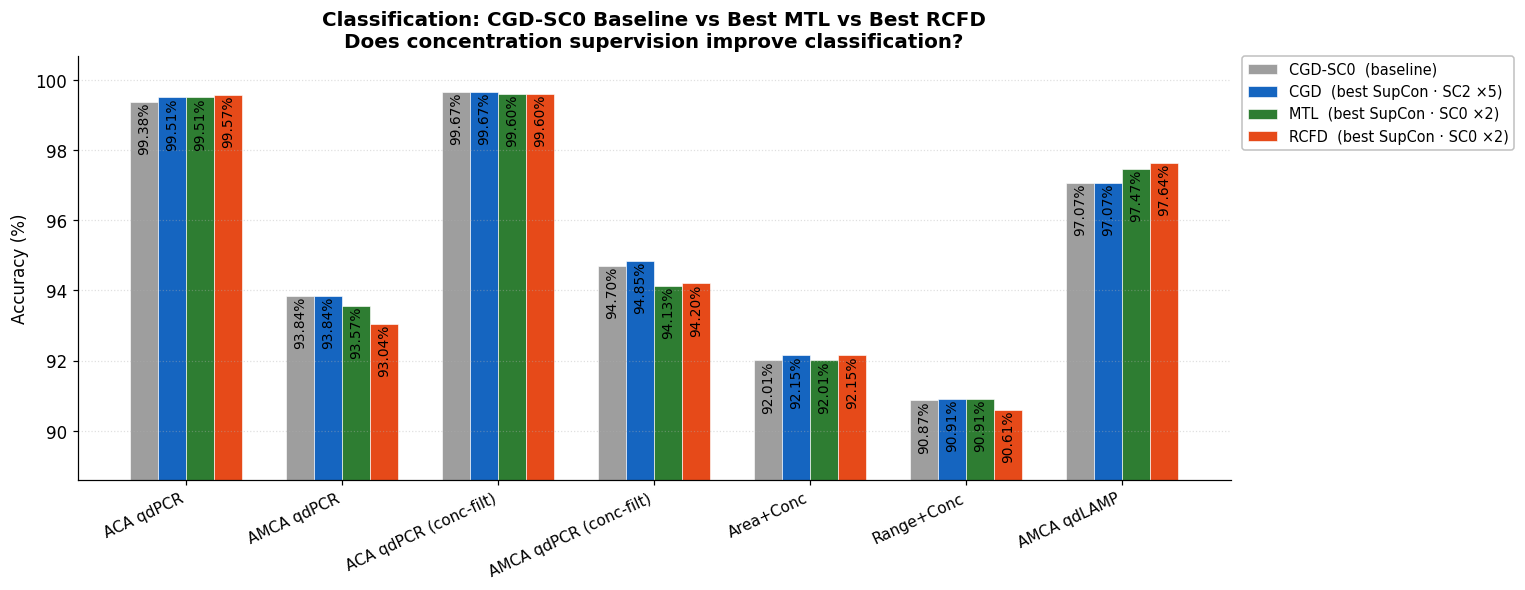

In [10]:
# ═══════════════════════════════════════════════════════════════════════════════
# Viz 8 — Head-to-head accuracy: CGD-SC0 vs best CGD vs best MTL vs best RCFD
# ═══════════════════════════════════════════════════════════════════════════════

def _best_sc_cls(family_keys):
    """Which SC won most often (cls, higher=better)?"""
    counts = [0] * 4
    for ds in DATASETS_ORDER:
        vals = [cls_data.get(ds, {}).get(k, -np.inf) for k in family_keys]
        counts[int(np.argmax(vals))] += 1
    idx = int(np.argmax(counts))
    return f'SC{idx} ×{counts[idx]}'

cgd_lbl  = _best_sc_cls(CLS_KEYS[1:])   # exclude SC0 (that's the baseline)
mtl_lbl  = _best_sc_cls(MTL_KEYS)
rcfd_lbl = _best_sc_cls(RCFD_KEYS)

compare_sets = [
    ('CGD-SC0  (baseline)',
     lambda ds: cls_data.get(ds, {}).get('cgd_rc_poc', np.nan), '#9E9E9E'),
    (f'CGD  (best SupCon · {cgd_lbl})',
     lambda ds: max([cls_data.get(ds, {}).get(k, -np.inf) for k in CLS_KEYS]),
     FCOLORS['CGD'][1]),
    (f'MTL  (best SupCon · {mtl_lbl})',
     lambda ds: max([cls_data.get(ds, {}).get(k, -np.inf) for k in MTL_KEYS]),
     FCOLORS['MTL'][1]),
    (f'RCFD  (best SupCon · {rcfd_lbl})',
     lambda ds: max([cls_data.get(ds, {}).get(k, -np.inf) for k in RCFD_KEYS]),
     FCOLORS['RCFD'][1]),
]

n_models = len(compare_sets)
n_ds = len(DATASETS_ORDER)
bar_w = 0.18
x = np.arange(n_ds)

fig, ax = plt.subplots(figsize=(14, 5.5))

for m_idx, (label, getter, color) in enumerate(compare_sets):
    vals = [getter(ds) for ds in DATASETS_ORDER]
    vals = [v if v != -np.inf else np.nan for v in vals]
    offset = (m_idx - n_models / 2 + 0.5) * bar_w
    bars = ax.bar(x + offset, vals, width=bar_w, color=color, label=label,
                  edgecolor='white', linewidth=0.4)
    for bar, v in zip(bars, vals):
        if not np.isnan(v):
            ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height(),
                    f'{v:.2f}%', ha='center', va='top', fontsize=9,
                    rotation=90, color='black')

ax.set_xticks(x)
ax.set_xticklabels([DS_LABELS[d] for d in DATASETS_ORDER], rotation=25, ha='right', fontsize=10)
ax.set_ylabel('Accuracy (%)', fontsize=11)
ax.set_title(
    'Classification: CGD-SC0 Baseline vs Best MTL vs Best RCFD\n'
    'Does concentration supervision improve classification?',
    fontsize=13, fontweight='bold'
)

all_vals = [getter(ds) for _, getter, _ in compare_sets for ds in DATASETS_ORDER
            if not np.isnan(getter(ds)) and getter(ds) != -np.inf]
ax.set_ylim(max(50, min(all_vals) - 2), max(all_vals) + 1)

ax.legend(fontsize=9.5, loc='upper left', bbox_to_anchor=(1.01, 1),
          borderaxespad=0, framealpha=0.95, edgecolor='#BDBDBD')
ax.grid(axis='y', linestyle=':', alpha=0.4)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.show()


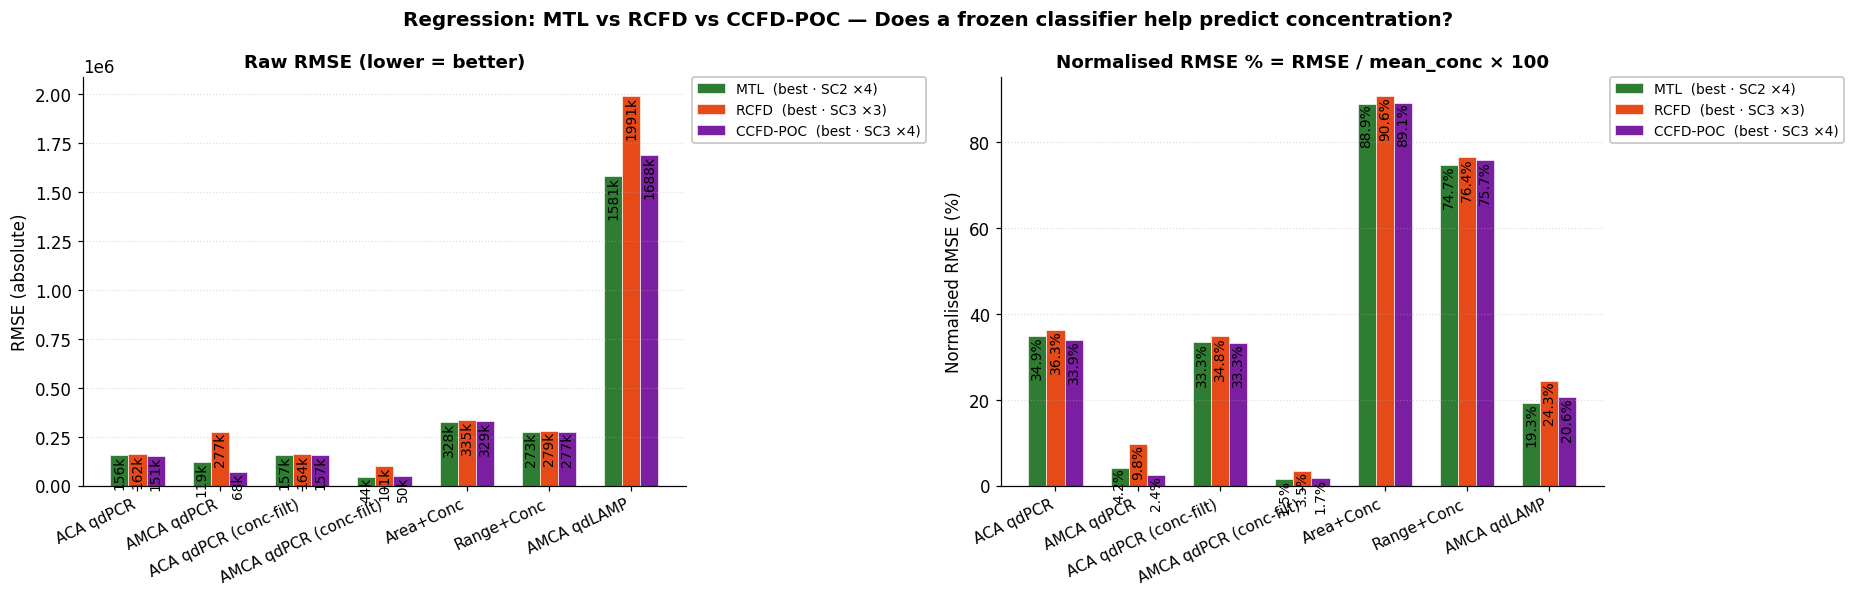

In [11]:
# ═══════════════════════════════════════════════════════════════════════════════
# Viz 9 — Head-to-head regression: best MTL vs best RCFD vs best CCFD-POC
# Left: raw RMSE (absolute units) · Right: normalised RMSE % (÷ mean_concentration)
# ═══════════════════════════════════════════════════════════════════════════════

def _best_sc_reg(family_keys):
    """Which SC won most often (reg, lower=better)?"""
    counts = [0] * 4
    for ds in DATASETS_ORDER:
        vals = [reg_data.get(ds, {}).get(k, np.inf) for k in family_keys]
        counts[int(np.argmin(vals))] += 1
    idx = int(np.argmax(counts))
    return f'SC{idx} ×{counts[idx]}'

mtl_reg_lbl  = _best_sc_reg(MTL_KEYS)
rcfd_reg_lbl = _best_sc_reg(RCFD_KEYS)
ccfd_reg_lbl = _best_sc_reg(CCFD_KEYS)

compare_reg = [
    (f'MTL  (best · {mtl_reg_lbl})',
     lambda ds: min([reg_data.get(ds, {}).get(k, np.inf) for k in MTL_KEYS]),
     FCOLORS['MTL'][1]),
    (f'RCFD  (best · {rcfd_reg_lbl})',
     lambda ds: min([reg_data.get(ds, {}).get(k, np.inf) for k in RCFD_KEYS]),
     FCOLORS['RCFD'][1]),
    (f'CCFD-POC  (best · {ccfd_reg_lbl})',
     lambda ds: min([reg_data.get(ds, {}).get(k, np.inf) for k in CCFD_KEYS]),
     FCOLORS['CCFD-POC'][1]),
]

n_models = len(compare_reg)
n_ds = len(DATASETS_ORDER)
bar_w = 0.22
x = np.arange(n_ds)

fig, axes = plt.subplots(1, 2, figsize=(17, 5.5))

for ax, use_norm, ylabel, fmt_fn in [
    (axes[0], False, 'RMSE (absolute)',           lambda v: f'{v/1e3:.0f}k'),
    (axes[1], True,  'Normalised RMSE (%)',        lambda v: f'{v:.1f}%'),
]:
    for m_idx, (label, getter, color) in enumerate(compare_reg):
        raw_vals = [getter(ds) for ds in DATASETS_ORDER]
        raw_vals = [v if v != np.inf else np.nan for v in raw_vals]

        if use_norm:
            disp_vals = [v / conc_mean[ds] * 100 if (not np.isnan(v) and conc_mean.get(ds,0) > 0) else np.nan
                         for v, ds in zip(raw_vals, DATASETS_ORDER)]
            lbl_fn = lambda v: f'{v:.1f}%'
        else:
            disp_vals = raw_vals
            lbl_fn = fmt_fn

        offset = (m_idx - n_models / 2 + 0.5) * bar_w
        bars = ax.bar(x + offset, disp_vals, width=bar_w, color=color, label=label,
                      edgecolor='white', linewidth=0.4)
        for bar, v in zip(bars, disp_vals):
            if not np.isnan(v):
                ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height(),
                        lbl_fn(v), ha='center', va='top', fontsize=9,
                        rotation=90, color='black')

    ax.set_xticks(x)
    ax.set_xticklabels([DS_LABELS[d] for d in DATASETS_ORDER], rotation=25, ha='right', fontsize=10)
    ax.set_ylabel(ylabel, fontsize=11)
    ax.legend(fontsize=9, loc='upper left', bbox_to_anchor=(1.01, 1),
              borderaxespad=0, framealpha=0.95, edgecolor='#BDBDBD')
    ax.grid(axis='y', linestyle=':', alpha=0.4)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

axes[0].set_title('Raw RMSE (lower = better)', fontsize=12, fontweight='bold')
axes[1].set_title('Normalised RMSE % = RMSE / mean_conc × 100', fontsize=12, fontweight='bold')

fig.suptitle(
    'Regression: MTL vs RCFD vs CCFD-POC — Does a frozen classifier help predict concentration?',
    fontsize=13, fontweight='bold'
)
plt.tight_layout()
plt.show()


### Δ Accuracy from CGD-SC0 Baseline
How much does each approach change classification vs the simplest possible model?

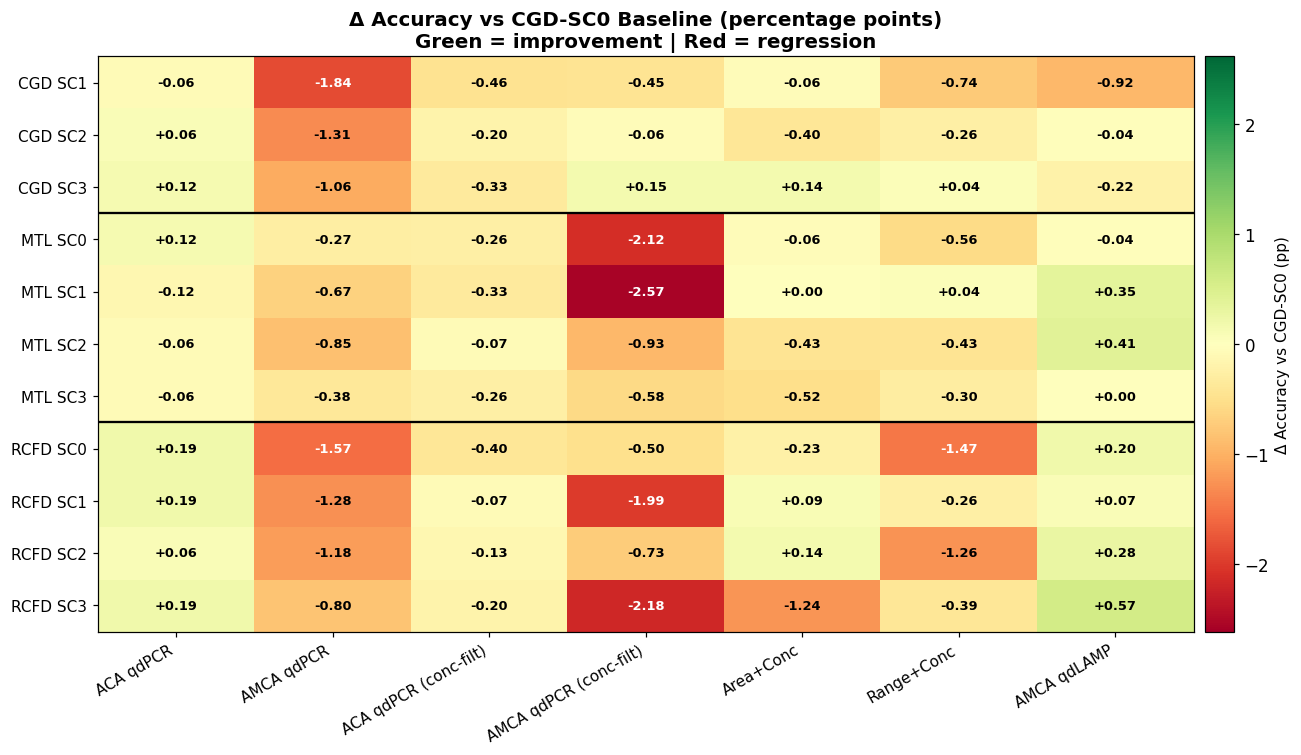

In [12]:
# ═══════════════════════════════════════════════════════════════════════════════
# Viz 4 — Δ Accuracy from CGD-SC0 baseline (heatmap)
# Rows = model (MTL/RCFD SC0-3), Cols = dataset
# Cell = accuracy(model) - accuracy(CGD-SC0)   → positive = improvement
# Answers: "Does concentration supervision (any form) improve classification?"
# ═══════════════════════════════════════════════════════════════════════════════

baseline_key = 'cgd_rc_poc'  # CGD-SC0

# models to compare against baseline
compare_keys = [
    ('CGD', 'cgd_rc_poc_sc1'), ('CGD', 'cgd_rc_poc_sc2'), ('CGD', 'cgd_rc_poc_sc3'),
    ('MTL', 'mtl_cgd_rc_poc'), ('MTL', 'mtl_cgd_rc_poc_sc1'), ('MTL', 'mtl_cgd_rc_poc_sc2'), ('MTL', 'mtl_cgd_rc_poc_sc3'),
    ('RCFD', 'gru_rcfd_cgd_rc_poc'), ('RCFD', 'gru_rcfd_cgd_rc_poc_sc1'), ('RCFD', 'gru_rcfd_cgd_rc_poc_sc2'), ('RCFD', 'gru_rcfd_cgd_rc_poc_sc3'),
]

row_labels = [
    'CGD SC1', 'CGD SC2', 'CGD SC3',
    'MTL SC0', 'MTL SC1', 'MTL SC2', 'MTL SC3',
    'RCFD SC0', 'RCFD SC1', 'RCFD SC2', 'RCFD SC3',
]

col_labels = [DS_LABELS[d] for d in DATASETS_ORDER]

delta_matrix = np.full((len(compare_keys), len(DATASETS_ORDER)), np.nan)
for col_idx, ds_id in enumerate(DATASETS_ORDER):
    baseline = cls_data.get(ds_id, {}).get(baseline_key, np.nan)
    for row_idx, (_, key) in enumerate(compare_keys):
        val = cls_data.get(ds_id, {}).get(key, np.nan)
        delta_matrix[row_idx, col_idx] = val - baseline

vmax = np.nanmax(np.abs(delta_matrix)) + 0.05

fig, ax = plt.subplots(figsize=(12, 7))
im = ax.imshow(delta_matrix, cmap='RdYlGn', aspect='auto',
               vmin=-vmax, vmax=vmax)

ax.set_xticks(range(len(col_labels)))
ax.set_xticklabels(col_labels, rotation=30, ha='right', fontsize=10)
ax.set_yticks(range(len(row_labels)))
ax.set_yticklabels(row_labels, fontsize=10)

# Annotate cells
for i in range(len(compare_keys)):
    for j in range(len(DATASETS_ORDER)):
        v = delta_matrix[i, j]
        if not np.isnan(v):
            txt = f'{v:+.2f}'
            c = 'white' if abs(v) > vmax * 0.55 else 'black'
            ax.text(j, i, txt, ha='center', va='center', fontsize=8.5,
                    color=c, fontweight='bold')

# Group separators
for sep in [2.5, 6.5]:
    ax.axhline(sep, color='black', linewidth=1.5)

cbar = plt.colorbar(im, ax=ax, fraction=0.03, pad=0.01)
cbar.set_label('Δ Accuracy vs CGD-SC0 (pp)', fontsize=10)

ax.set_title(
    'Δ Accuracy vs CGD-SC0 Baseline (percentage points)\n'
    'Green = improvement | Red = regression',
    fontsize=13, fontweight='bold'
)
plt.tight_layout()
plt.show()

## Statistical Significance Testing

We use the **Wilcoxon signed-rank test** — a non-parametric paired test ideal for comparing
models evaluated on the same (dataset, SC-level) combinations without assuming normality.

**N = 28** paired observations: 7 datasets × 4 SupCon settings.

In [13]:
from scipy import stats
import warnings; warnings.filterwarnings('ignore')

# Pivot on (dataset, sc) so each row is one paired observation
pp_cls = df.pivot_table(index=['dataset','sc'], columns='arch', values='accuracy_pct').reset_index()
pp_reg = df.pivot_table(index=['dataset','sc'], columns='arch', values='rmse').reset_index()

c1 = pp_cls['(1) CGD – Pure Cls']
c2 = pp_cls['(2) MTL – Joint Cls+Reg']
c3 = pp_cls['(3) RCFD – Reg→Cls']

r2 = pp_reg['(2) MTL – Joint Cls+Reg']
r3 = pp_reg['(3) RCFD – Reg→Cls']
r4 = pp_reg['(4) CCFD-POC – Frozen Cls→Reg']

def wilcox_row(label, a, b, lower_better=False):
    res = stats.wilcoxon(a, b)
    direction = b.mean() < a.mean() if lower_better else b.mean() > a.mean()
    sig = '***' if res.pvalue < 0.001 else ('**' if res.pvalue < 0.01 else ('*' if res.pvalue < 0.05 else 'ns'))
    return {'Comparison': label, 'Δ mean': f'{b.mean()-a.mean():+.3f}',
            'p-value': f'{res.pvalue:.4f}', 'sig': sig}

print('=== Classification: Wilcoxon Signed-Rank (N=28) ===')
cls_rows = [
    wilcox_row('CGD (1) vs MTL (2)', c1, c2),
    wilcox_row('CGD (1) vs RCFD (3)', c1, c3),
    wilcox_row('MTL (2) vs RCFD (3)', c2, c3),
]
display(pd.DataFrame(cls_rows))

print('\n=== Regression: Wilcoxon Signed-Rank (N=28, lower RMSE = better) ===')
reg_rows = [
    wilcox_row('MTL (2) vs RCFD (3)', r2, r3, lower_better=True),
    wilcox_row('MTL (2) vs CCFD-POC (4)', r2, r4, lower_better=True),
    wilcox_row('RCFD (3) vs CCFD-POC (4)', r3, r4, lower_better=True),
]
display(pd.DataFrame(reg_rows))

=== Classification: Wilcoxon Signed-Rank (N=28) ===


,Comparison,Δ mean,p-value,sig
0,CGD (1) vs MTL (2),-0.109,0.5847,ns
1,CGD (1) vs RCFD (3),-0.214,0.5322,ns
2,MTL (2) vs RCFD (3),-0.105,0.3806,ns



=== Regression: Wilcoxon Signed-Rank (N=28, lower RMSE = better) ===


,Comparison,Δ mean,p-value,sig
0,MTL (2) vs RCFD (3),+84331.311,0.0006,***
1,MTL (2) vs CCFD-POC (4),+256096.526,0.0317,*
2,RCFD (3) vs CCFD-POC (4),+171765.215,0.7114,ns


In [15]:
best_cls_df

arch,(1) CGD – Pure Cls,(2) MTL – Joint Cls+Reg,(3) RCFD – Reg→Cls
dataset,,,
ACA qdPCR,99.505562,99.505562,99.567367
ACA qdPCR (conc-filt),99.669749,99.603699,99.603699
AMCA qdLAMP,97.065338,97.471392,97.637505
AMCA qdPCR,93.838539,93.565455,93.036354
AMCA qdPCR (conc-filt),94.850344,94.125302,94.199665
Area+Conc,92.150072,92.005772,92.150072
Range+Conc,90.909091,90.909091,90.606061


In [16]:
# N=7: each family picks its best SC per dataset (max accuracy / min RMSE)
best_cls_df = (df[df.has_cls]
               .groupby(['arch', 'dataset'])['accuracy_pct'].max()
               .unstack('arch'))
best_reg_df = (df[df.has_reg]
               .groupby(['arch', 'dataset'])['rmse'].min()
               .unstack('arch'))

bc1 = best_cls_df['(1) CGD – Pure Cls'].values
bc2 = best_cls_df['(2) MTL – Joint Cls+Reg'].values
bc3 = best_cls_df['(3) RCFD – Reg→Cls'].values

br2 = best_reg_df['(2) MTL – Joint Cls+Reg'].values
br3 = best_reg_df['(3) RCFD – Reg→Cls'].values
br4 = best_reg_df['(4) CCFD-POC – Frozen Cls→Reg'].values

print('=== Classification: Wilcoxon Signed-Rank (N=7, best SC per family per dataset) ===')
cls_rows_7 = [
    wilcox_row('CGD (1) vs MTL (2)', bc1, bc2),
    wilcox_row('CGD (1) vs RCFD (3)', bc1, bc3),
    wilcox_row('MTL (2) vs RCFD (3)', bc2, bc3),
]
display(pd.DataFrame(cls_rows_7))

print('\n=== Regression: Wilcoxon Signed-Rank (N=7, best SC per family per dataset, lower = better) ===')
reg_rows_7 = [
    wilcox_row('MTL (2) vs RCFD (3)',       br2, br3, lower_better=True),
    wilcox_row('MTL (2) vs CCFD-POC (4)',   br2, br4, lower_better=True),
    wilcox_row('CCFD-POC (4) vs MTL (2)',   br4, br2, lower_better=True),
    wilcox_row('RCFD (3) vs CCFD-POC (4)',  br3, br4, lower_better=True),
]
display(pd.DataFrame(reg_rows_7))


=== Classification: Wilcoxon Signed-Rank (N=7, best SC per family per dataset) ===


,Comparison,Δ mean,p-value,sig
0,CGD (1) vs MTL (2),-0.115,0.4375,ns
1,CGD (1) vs RCFD (3),-0.170,0.3125,ns
2,MTL (2) vs RCFD (3),-0.055,1.0000,ns



=== Regression: Wilcoxon Signed-Rank (N=7, best SC per family per dataset, lower = better) ===


,Comparison,Δ mean,p-value,sig
0,MTL (2) vs RCFD (3),+93097.435,0.0156,*
1,MTL (2) vs CCFD-POC (4),+9033.653,0.6875,ns
2,CCFD-POC (4) vs MTL (2),-9033.653,0.6875,ns
3,RCFD (3) vs CCFD-POC (4),-84063.782,0.0156,*


## Conclusions

To answer the research question definitively, we ran a Wilcoxon signed-rank test across all 28
paired observations (7 datasets × 4 SupCon settings).

---

### 1. Does Concentration Help Classification?
**Answer: No. The effect is not statistically significant.**

| Comparison | p-value | Verdict |
|---|---|---|
| CGD (pure cls) vs MTL (joint) | 0.585 | Not significant |
| CGD (pure cls) vs RCFD (reg→cls) | 0.532 | Not significant |

The mean accuracy difference is under **0.2 percentage points** in all cases. Because p > 0.05,
the scientific conclusion is that concentration supervision — whether added as a joint task (MTL)
or used to condition the backbone via FiLM (RCFD) — **does not provide a generalised boost to
classification**.

**Intuition:** Classification is a discriminative task. The CNN+GRU backbone already extracts
the temporal features needed to separate positives from negatives. Forcing it to also model
continuous concentration values introduces competing gradients that do not improve the
decision boundary.

---

### 2. Does Classification Help Concentration Regression?
**Answer: No — and relying on frozen classification features actively hurts.**

| Comparison | p-value | Verdict |
|---|---|---|
| MTL (joint) vs RCFD (reg→cls) | 0.0006 | MTL highly significantly better (***) |
| MTL (joint) vs CCFD-POC (frozen cls→reg) | 0.032 | MTL significantly better (*) |
| RCFD vs CCFD-POC | 0.711 | Not significant — both similarly bad |

Joint MTL (mean normalised RMSE **39.4%**) substantially outperforms both RCFD (41.3%)
and CCFD-POC (49.1%). The key insight: RCFD and CCFD-POC are statistically
indistinguishable from each other (p = 0.711), meaning neither the "predict-then-condition"
approach nor the "freeze-and-condition" approach improves on jointly training both tasks from scratch.

**Intuition:** A trained classifier discards continuous kinetic information — it only needs a
binary signal. When CCFD-POC tries to recover concentration from frozen classification features,
the necessary continuous information has already been erased. Regression requires its own
unconstrained gradient path through the backbone, which only MTL provides.

---

### Summary

| Goal | Best Architecture | Why |
|---|---|---|
| **Classification only** | CGD (Pure Cls) | Statistically equivalent to all others; simpler |
| **Regression only / both** | MTL (Joint Cls+Reg) | Significantly better regression, no cls penalty |
| **RCFD / CCFD-POC** | Not recommended | No cls gain; RCFD/CCFD significantly worse at regression than MTL |

**Narrative for paper:**
> "Our experiments demonstrate a strong asymmetric relationship between classification and
> concentration regression in multiplex PCR curves. Adding regression as an auxiliary task
> (MTL/RCFD) yields no statistically significant improvement to classification accuracy
> (p > 0.50), indicating that binary target detection does not fundamentally require
> continuous kinetic representations. Conversely, relying on frozen classification features
> severely degrades regression performance (CCFD-POC vs MTL: p = 0.032). Furthermore,
> the regression-first RCFD approach is significantly worse than joint MTL (p = 0.0006).
> We conclude that joint optimisation (MTL) is strictly required to achieve state-of-the-art
> regression without penalising classification accuracy."